Metrics visualisation and models comparison

# Libraries

In [96]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Metrics visualisation

In [97]:
df_metrics = pd.read_excel(r'..\results\metrics_modelling2_filtered_optuna.xlsx', index_col=[0])

In [98]:
dict_best_models = {}
dict_best_models['splashing'] = {
    'sklearn': df_metrics.iloc[60],
    'boosting': df_metrics.iloc[50]}
dict_best_models['net_impact'] = {
    'sklearn': df_metrics.iloc[38],
    'boosting': df_metrics.iloc[0]}

In [99]:
df_best_models = pd.DataFrame()
for key in dict_best_models.keys():
    for key_type in dict_best_models[key]:
        df_best_models = pd.concat((df_best_models, dict_best_models[key][key_type]), axis=1)
df_best_models = df_best_models.T

In [100]:
path_metric_plots = Path('../results/best_models_comparison_modelling_2')
if not os.path.exists(path_metric_plots): os.makedirs(path_metric_plots)

# Splashing

In [101]:
df_best_models_splashing = df_best_models[df_best_models['target']=='splashing'].copy()
df_best_models_splashing['model'] = df_best_models_splashing['model'].replace({'svc_smote_splashing_ordenc': 'SVM',
                                           'catboostclassifier_smote_splashing': 'CatBoost'})

In [102]:
metrics_columns = [
    'accuracy', 'f1', 'precision', 'recall', 'roc_auc']
metrics_values = np.hstack(df_best_models_splashing[metrics_columns].values.T)
metrics_names = np.hstack([(x, x) for x in metrics_columns])
models_names = list(df_best_models_splashing['model'].values) * len(metrics_columns)

In [103]:
df_plot = pd.DataFrame(
    {'Model': models_names,
     'Metric': metrics_names,
     'Value': metrics_values})
df_plot['Metric'] = df_plot['Metric'].replace({'accuracy': 'Accuracy',
                           'f1': 'F1',
                           'precision': 'Precision',
                           'recall': 'Recall',
                           'roc_auc': 'ROC-AUC'})
df_plot['Value'] = df_plot['Value'].astype(float).round(3)

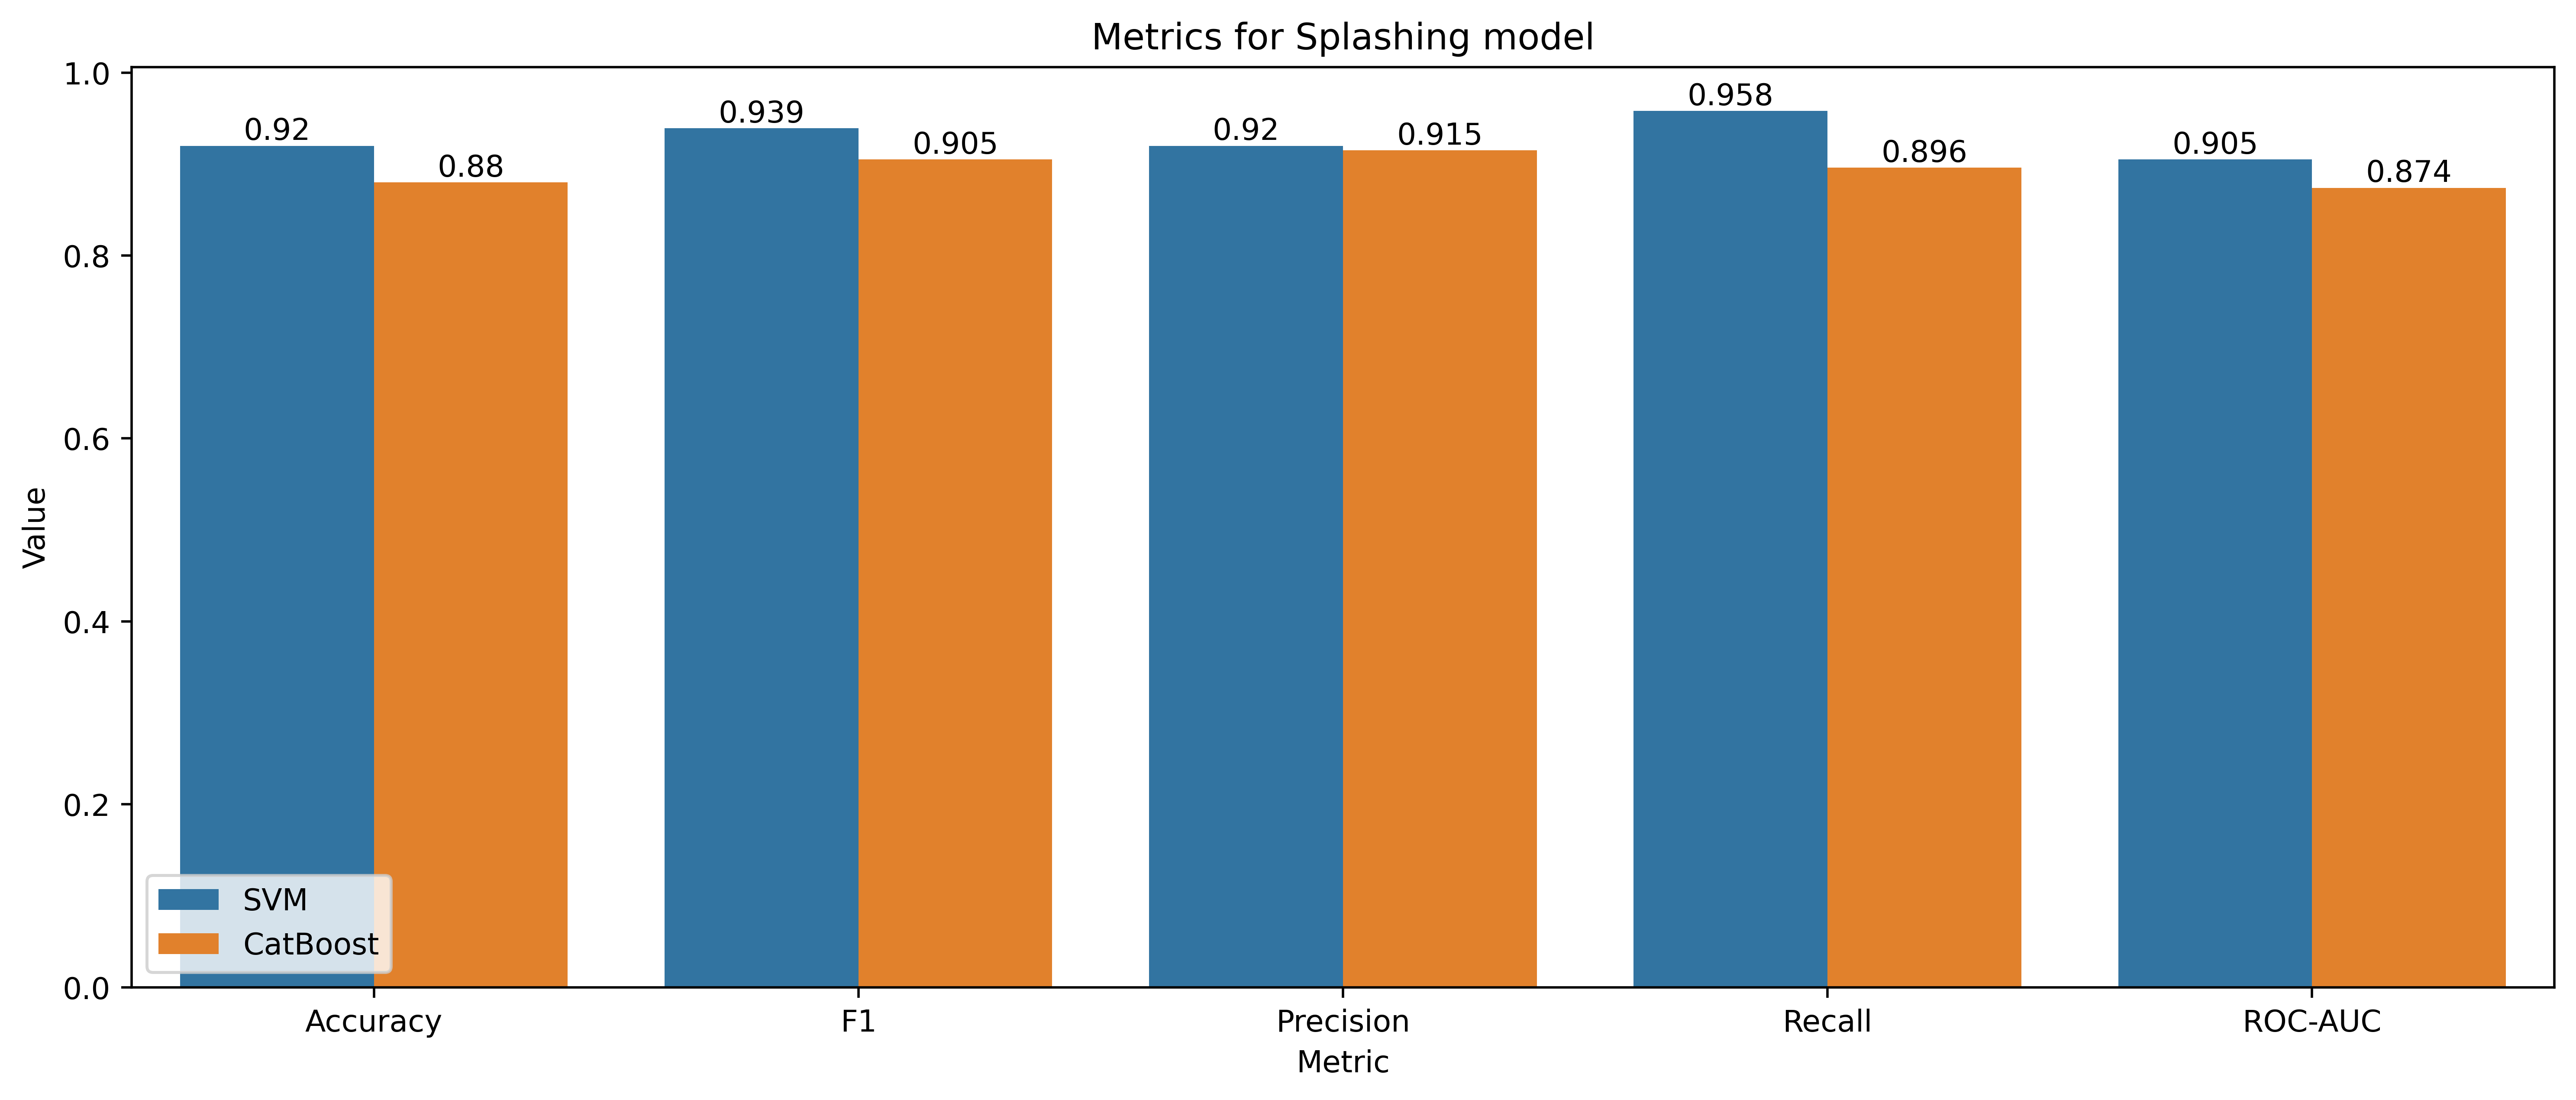

In [104]:
plt.figure(figsize=(12, 5), dpi=500)
ax = sns.barplot(
    data=df_plot,
    orient='v', hue='Model',
    y='Value', x='Metric')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.tight_layout()
plt.legend(loc='lower left')
plt.title('Metrics for Splashing model')
plt.savefig(path_metric_plots / 'splashing_metrics.pdf', bbox_inches='tight')
plt.show()

# Net impact

In [105]:
df_best_models_net_impact = df_best_models[df_best_models['target']=='net_impact'].copy()
df_best_models_net_impact['model'] = df_best_models_net_impact['model'].replace({'kneighborsclassifier_net_impact_onehot': 'KNN',
                                           'catboostclassifier_net_impact': 'CatBoost'})

In [106]:
metrics_columns = [
    'accuracy', 'f1', 'precision', 'recall', 'roc_auc']
metrics_values = np.hstack(df_best_models_net_impact[metrics_columns].values.T)
metrics_names = np.hstack([(x, x) for x in metrics_columns])
models_names = list(df_best_models_net_impact['model'].values) * len(metrics_columns)

In [107]:
df_plot = pd.DataFrame(
    {'Model': models_names,
     'Metric': metrics_names,
     'Value': metrics_values})
df_plot['Metric'] = df_plot['Metric'].replace({'accuracy': 'Accuracy',
                           'f1': 'F1',
                           'precision': 'Precision',
                           'recall': 'Recall',
                           'roc_auc': 'ROC-AUC'})
df_plot['Value'] = df_plot['Value'].astype(float).round(3)

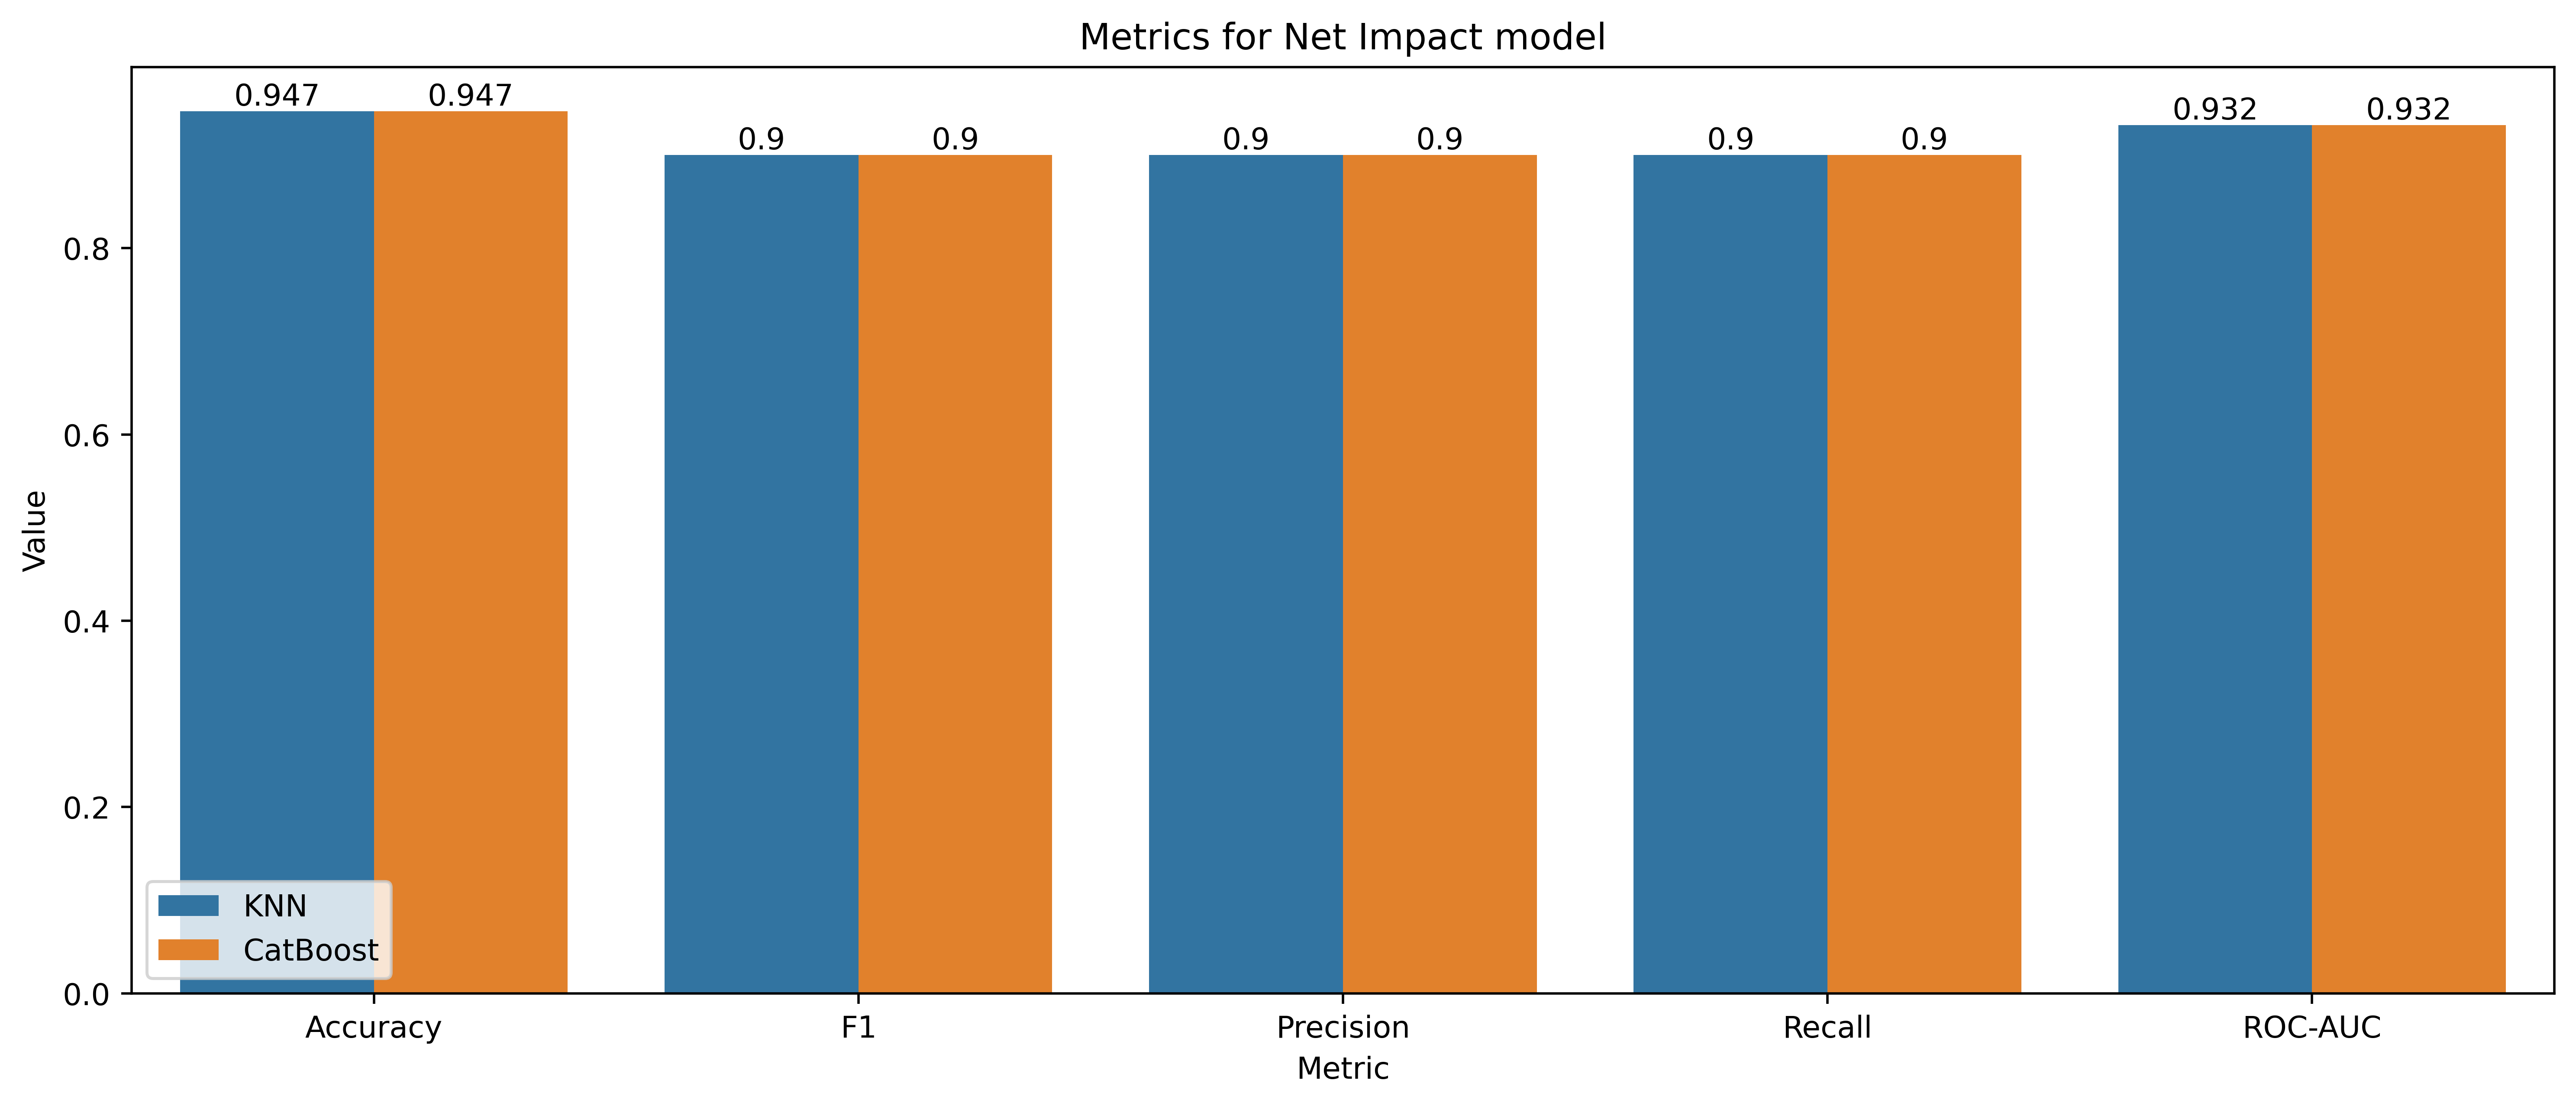

In [108]:
plt.figure(figsize=(12, 5), dpi=500)
ax = sns.barplot(
    data=df_plot,
    orient='v', hue='Model',
    y='Value', x='Metric')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.tight_layout()
plt.legend(loc='lower left')
plt.title('Metrics for Net Impact model')
plt.savefig(path_metric_plots / 'net_impact_metrics.pdf', bbox_inches='tight')
plt.show()